# Sequential Data and Recurrent Neural Networks

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snss
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## Sequential dataset: Lorenz system

In [3]:
from scipy.integrate import solve_ivp

def lorenz(t, x, sigma=10., beta=8./3., rho=28):
    return [
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1]  - beta * x[2]
    ]

def generate_lorenz(t_max=20, dt=0.02, x0=None, sigma=10., beta=8./3., rho=28):
    if x0 is None:
        x0 = -15 + 30 * np.random.uniform(size=3)
    t_eval = np.arange(0, t_max, dt)
    func = lambda t, x: lorenz(t, x, sigma=sigma, beta=beta, rho=rho)
    x = solve_ivp(func, (t_eval[0], t_eval[-1]), x0, t_eval=t_eval, rtol=1e-8, atol=1e-8).y.T
    return x

(1000, 3)


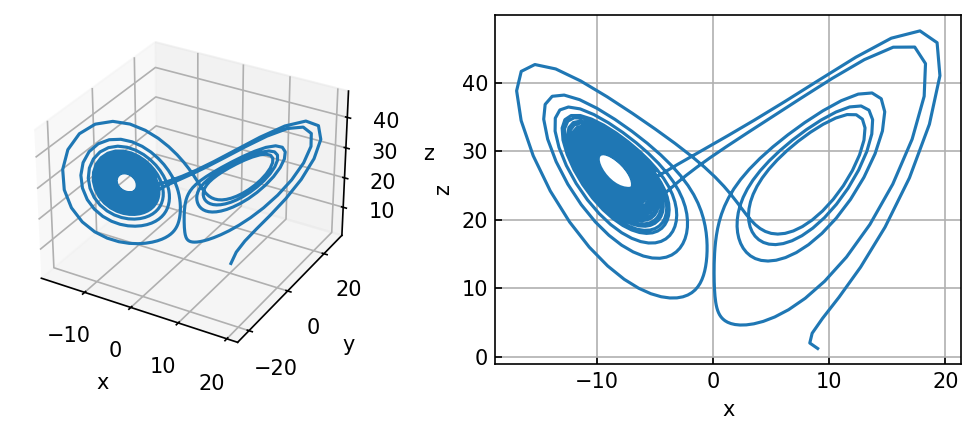

In [4]:
x = generate_lorenz()
print(x.shape)

fig = plt.figure(figsize=(7, 3))
ax = fig.add_subplot(121, projection='3d')
ax.plot(
    x[:, 0],
    x[:, 1],
    x[:, 2]
)
ax.set(xlabel='x', ylabel='y', zlabel='z')

ax = fig.add_subplot(122)
ax.plot(x[:, 0], x[:, 2])
ax.set(xlabel='x', ylabel='z')

plt.tight_layout()

MLP Train Dataset has 19980 examples
RNN Train Dataset has 19600 sequences


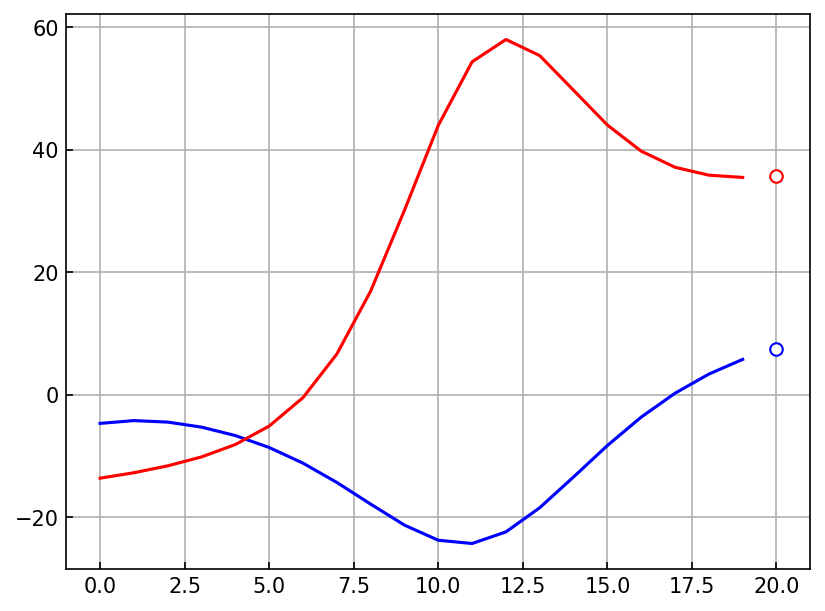

In [5]:
from torch.utils.data import Dataset, ConcatDataset

class PairDataset(Dataset):
    def __init__(self, x, seq_stride=1):
        self.x = x
        self.seq_stride = seq_stride

    def __len__(self):
        return len(self.x) - self.seq_stride

    def __getitem__(self, idx):
        """ Return the idx element of the sequence and the one after it
        """
        x = self.x[idx, (0, 2)]
        y = self.x[idx + self.seq_stride, (0, 2)]
        return torch.FloatTensor(x), torch.FloatTensor(y)

class SequenceDataset(Dataset):
    def __init__(self, x, seq_len=20, seq_stride=1):
        self.x = x
        self.seq_len = seq_len
        self.seq_stride = seq_stride

    def __len__(self):
        return len(self.x) - self.seq_len * self.seq_stride

    def __getitem__(self, idx):
        """ Return a sequence of length self.seq_len with stride self.seq_stride
            paired with the next element of the sequence
        """
        slc = slice(idx, idx + (self.seq_len + 1) * self.seq_stride, self.seq_stride)
        x = torch.FloatTensor(self.x[slc])
        x = x[:, (0, 2)] # Only the (x, z) coordinates
        return x[:-1], x[-1] # For each element, predict the next element in the sequence

train_sequences = [generate_lorenz() for i in range(20)]
val_sequences = [generate_lorenz() for i in range(4)]

mlp_train_dataset = ConcatDataset([PairDataset(seq) for seq in train_sequences])
mlp_val_dataset = ConcatDataset([PairDataset(seq) for seq in val_sequences])
print(f"MLP Train Dataset has {len(mlp_train_dataset)} examples")

rnn_train_dataset = ConcatDataset([SequenceDataset(seq) for seq in train_sequences])
rnn_val_dataset = ConcatDataset([SequenceDataset(seq) for seq in val_sequences])
print(f"RNN Train Dataset has {len(rnn_train_dataset)} sequences")

x, y = rnn_train_dataset[0]

ax = plt.figure().gca()
t = np.arange(len(x))
ax.plot(t, x[:, 0], color='blue')
ax.plot(t[-1] + 1, y[0], color='blue', marker='o', markerfacecolor='white')

ax.plot(t, x[:, 1], color='red')
ax.plot(t[-1] + 1, y[1], color='red', marker='o', markerfacecolor='white')

# ax.plot(t, x[:, 2], color='black')
# ax.plot(t + 1, y[:, 2], color='black', marker='o', markerfacecolor='white')

## Baseline: MLP

In [6]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, random_split
from tqdm import trange

def train(model, optimizer, loss_func, train_dataset, val_dataset, batch_size=64, num_epochs=10, num_workers=4):
    model = model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

    train_loss = []
    train_mad = []
    val_loss = []
    val_mad = []

    pbar_epoch = trange(num_epochs)
    for ii in pbar_epoch:
        model.train()
        train_loss_ = 0.
        train_mad_ = 0.
        for xb, yb in train_loader:
            # Send data to device
            xb = xb.to(device)
            yb = yb.to(device)

            # Make a prediction, compute the loss
            y_pred = model(xb)
            loss = loss_func(y_pred, yb)

            # Backpropagate, apply gradient updates, zero gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * yb.shape[0]
            train_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()
            
        train_loss.append(train_loss_ / len(train_loader.dataset))
        train_mad.append(train_mad_ / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            val_loss_ = 0.
            val_mad_ = 0.
            for xb, yb in val_loader:
                # Send data to device
                xb = xb.to(device)
                yb = yb.to(device)
                
                # Make a prediction, compute the loss
                y_pred = model(xb)
                loss = loss_func(y_pred, yb)

                # Logging
                val_loss_ += loss.item() * yb.shape[0]
                val_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()
                
            val_loss.append(val_loss_ / len(val_loader.dataset))
            val_mad.append(val_mad_ / len(val_loader.dataset))

        pbar_epoch.set_postfix(
            epoch=f"{ii+1:03d} / {num_epochs:03d}",
            train_loss=f"{train_loss[-1]:.3f}",
            train_MAD=f"{train_mad[-1]:.3f}",
            val_loss=f"{val_loss[-1]:.3f}",
            val_MAD=f"{val_mad[-1]:.3f}")
        # Consider early stopping
        # Consider learning rate scheduling

    return model, (train_loss, train_mad, val_loss, val_mad)

In [7]:
mlp_model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
mlp_model, mlp_stats = train(mlp_model, optimizer, loss, mlp_train_dataset, mlp_val_dataset, num_epochs=50)

100%|██████████| 50/50 [01:10<00:00,  1.40s/it, epoch=050 / 050, train_MAD=0.338, train_loss=0.112, val_MAD=0.388, val_loss=0.125]


In [8]:
class RNN_Sequence_Forecast(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2, 128, num_layers=1, batch_first=True)
        self.linear = nn.Linear(128, 2)
        
    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        output = self.linear(output[:, -1])
        return output
        
rnn_model = RNN_Sequence_Forecast().to(device)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)
rnn_model, rnn_stats = train(rnn_model, optimizer, loss, rnn_train_dataset, rnn_val_dataset, num_epochs=50)

100%|██████████| 50/50 [01:20<00:00,  1.61s/it, epoch=050 / 050, train_MAD=0.051, train_loss=0.001, val_MAD=0.045, val_loss=0.001]  


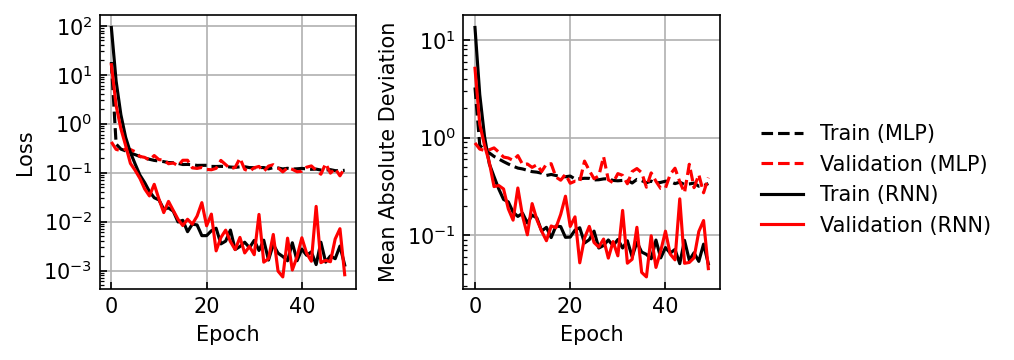

In [9]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(mlp_stats[0], color='black', linestyle='--', label='Train (MLP)')
ax[0].plot(mlp_stats[2], color='red', linestyle='--', label='Validation (MLP)')
ax[0].plot(rnn_stats[0], color='black', label='Train (RNN)')
ax[0].plot(rnn_stats[2], color='red', label='Validation (RNN)')
ax[0].set(xlabel='Epoch', ylabel='Loss', yscale='log')

ax[1].plot(mlp_stats[1], color='black', linestyle='--', label='Train (MLP)')
ax[1].plot(mlp_stats[3], color='red', linestyle='--', label='Validation (MLP)')
ax[1].plot(rnn_stats[1], color='black', label='Train (RNN)')
ax[1].plot(rnn_stats[3], color='red', label='Validation (RNN)')
ax[1].set(xlabel='Epoch', ylabel='Mean Absolute Deviation', yscale='log')

fig.legend(*ax[1].get_legend_handles_labels(), 
        loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

100%|██████████| 480/480 [00:00<00:00, 18961.59it/s]


MLP Mean Absolute Error: 8.218
RNN Mean Absolute Error: 6.741


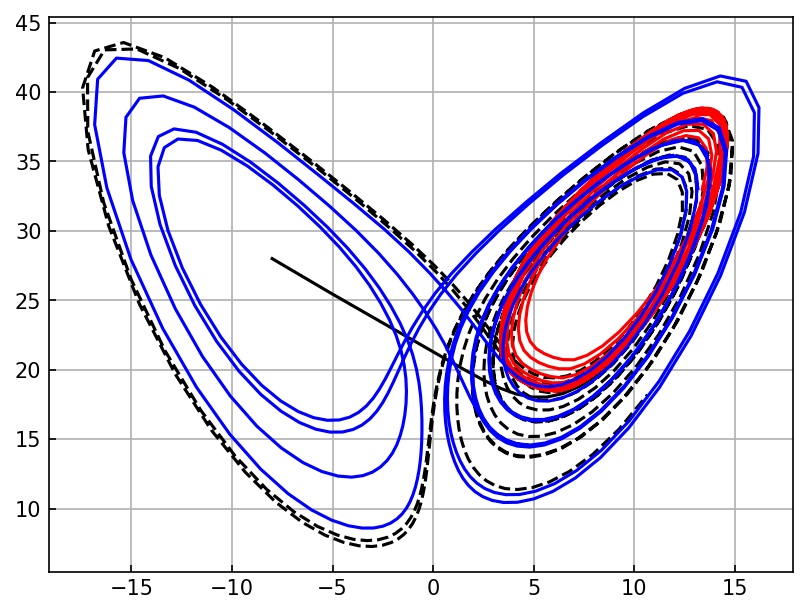

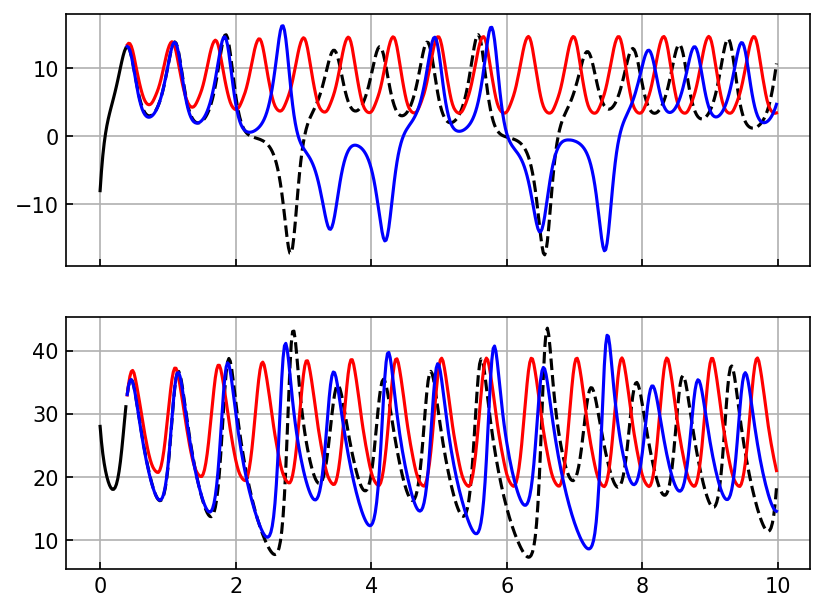

In [45]:
# Create a test sequence
t_max = 10
t = np.arange(0, t_max, 0.02)
test = generate_lorenz(t_max=t_max, x0=[-8, 8, 28])
split = 20

# Forecast second half from first half
with torch.no_grad():
    xy = torch.FloatTensor(test).to(device)
    xy = xy[:, (0, 2)]

    x = xy[:split]
    y = xy[split:]

    # Forecast with MLP
    x_in = x[-1:]
    y_mlp = []
    for ii in trange(len(y)):
        y_mlp.append(mlp_model(x_in))
        x_in = y_mlp[-1]
    y_mlp = torch.concat(y_mlp, dim=0)
    print(f'MLP Mean Absolute Error: {F.l1_loss(y_mlp, y):.3f}')

    # Forecast with LSTM
    x_in = x[None]
    output = []
    for ii in range(len(y)):
        x_out = rnn_model(x_in)
        output.append(x_out)
        x_in = torch.concat([x_in[:, 1:], x_out[:, None]], dim=1)
        
    output = torch.stack(output, dim=1)
    y_rnn = output[0]
    print(f'RNN Mean Absolute Error: {F.l1_loss(y_rnn, y):.3f}')

fig, ax = plt.subplots(1, 1)
ax.plot(x[:, 0].cpu(), x[:, 1].cpu(), color='black')
ax.plot(y[:, 0].cpu(), y[:, 1].cpu(), color='black', linestyle='--')
ax.plot(y_mlp[:, 0].cpu(), y_mlp[:, 1].cpu(), color='red')
ax.plot(y_rnn[:, 0].cpu(), y_rnn[:, 1].cpu(), color='blue')

fig, ax = plt.subplots(2, 1, sharex=True)

for ii, a in enumerate(ax):
    a.plot(t[:split], x[:, ii].cpu(), color='black')
    a.plot(t[split:], y[:, ii].cpu(), color='black', linestyle='--')
    a.plot(t[split:], y_mlp[:, ii].cpu(), color='red')
    a.plot(t[split:], y_rnn[:, ii].cpu(), color='blue')

## Residual structure

In [30]:
class RNN_Residual_Forecast(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2, 128, num_layers=1, batch_first=True)
        self.linear = nn.Linear(128, 2)
        
    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        dx = self.linear(output[:, -1])
        return x[:, -1] + dx
        
res_model = RNN_Residual_Forecast().to(device)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(res_model.parameters(), lr=1e-3)
res_model, res_stats = train(res_model, optimizer, loss, rnn_train_dataset, rnn_val_dataset, num_epochs=50)

100%|██████████| 50/50 [01:21<00:00,  1.62s/it, epoch=050 / 050, train_MAD=0.024, train_loss=0.000, val_MAD=0.057, val_loss=0.001]


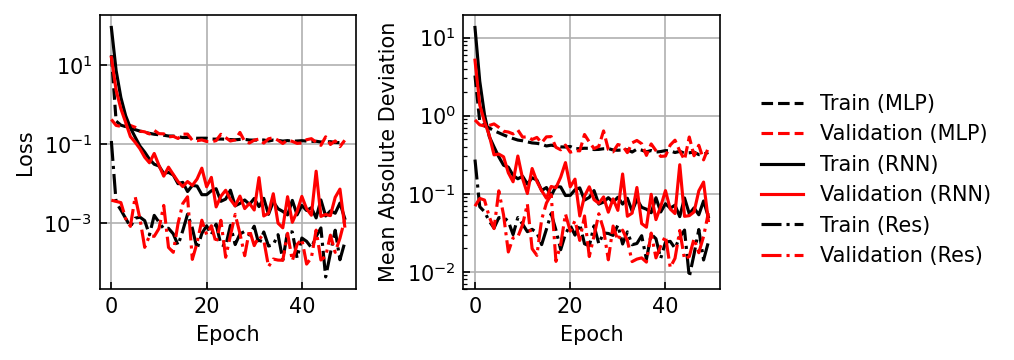

In [31]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(mlp_stats[0], color='black', linestyle='--', label='Train (MLP)')
ax[0].plot(mlp_stats[2], color='red', linestyle='--', label='Validation (MLP)')
ax[0].plot(rnn_stats[0], color='black', label='Train (RNN)')
ax[0].plot(rnn_stats[2], color='red', label='Validation (RNN)')
ax[0].plot(res_stats[0], color='black', linestyle='-.', label='Train (Res)')
ax[0].plot(res_stats[2], color='red', linestyle='-.', label='Validation (Res)')
ax[0].set(xlabel='Epoch', ylabel='Loss', yscale='log')

ax[1].plot(mlp_stats[1], color='black', linestyle='--', label='Train (MLP)')
ax[1].plot(mlp_stats[3], color='red', linestyle='--', label='Validation (MLP)')
ax[1].plot(rnn_stats[1], color='black', label='Train (RNN)')
ax[1].plot(rnn_stats[3], color='red', label='Validation (RNN)')
ax[1].plot(res_stats[1], color='black', linestyle='-.', label='Train (Res)')
ax[1].plot(res_stats[3], color='red', linestyle='-.', label='Validation (Res)')
ax[1].set(xlabel='Epoch', ylabel='Mean Absolute Deviation', yscale='log')

fig.legend(*ax[1].get_legend_handles_labels(), 
        loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

100%|██████████| 480/480 [00:00<00:00, 18135.24it/s]


MLP Mean Absolute Error: 8.218
Residual RNN Mean Absolute Error: 7.341


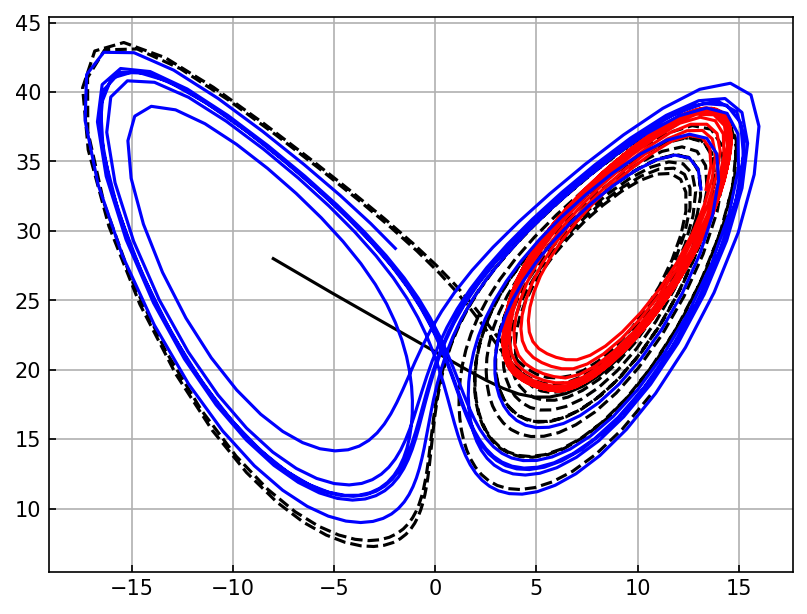

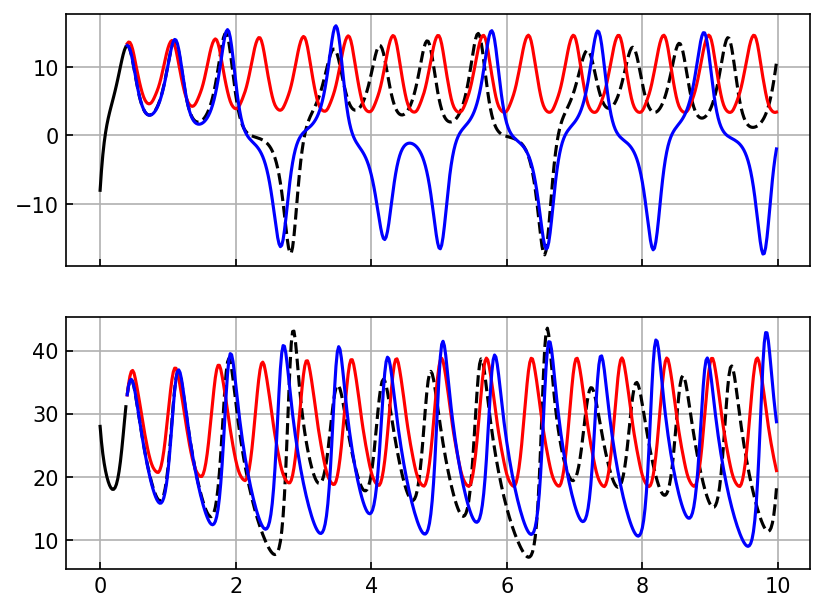

In [46]:
# Forecast second half of test sequence from first half
with torch.no_grad():
    xy = torch.FloatTensor(test).to(device)
    xy = xy[:, (0, 2)]

    x = xy[:split]
    y = xy[split:]

    # Forecast with MLP
    x_in = x[-1:]
    y_mlp = []
    for ii in trange(len(y)):
        y_mlp.append(mlp_model(x_in))
        x_in = y_mlp[-1]
    y_mlp = torch.concat(y_mlp, dim=0)
    print(f'MLP Mean Absolute Error: {F.l1_loss(y_mlp, y):.3f}')

    # Forecast with LSTM
    x_in = x[None]
    output = []
    for ii in range(len(y)):
        x_out = res_model(x_in)
        output.append(x_out)
        x_in = torch.concat([x_in[:, 1:], x_out[:, None]], dim=1)
        
    output = torch.stack(output, dim=1)
    y_rnn = output[0]
    print(f'Residual RNN Mean Absolute Error: {F.l1_loss(y_rnn, y):.3f}')

fig, ax = plt.subplots(1, 1)
ax.plot(x[:, 0].cpu(), x[:, 1].cpu(), color='black')
ax.plot(y[:, 0].cpu(), y[:, 1].cpu(), color='black', linestyle='--')
ax.plot(y_mlp[:, 0].cpu(), y_mlp[:, 1].cpu(), color='red')
ax.plot(y_rnn[:, 0].cpu(), y_rnn[:, 1].cpu(), color='blue')

fig, ax = plt.subplots(2, 1, sharex=True)

for ii, a in enumerate(ax):
    a.plot(t[:split], x[:, ii].cpu(), color='black')
    a.plot(t[split:], y[:, ii].cpu(), color='black', linestyle='--')
    a.plot(t[split:], y_mlp[:, ii].cpu(), color='red')
    a.plot(t[split:], y_rnn[:, ii].cpu(), color='blue')